In [ ]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
from scipy.stats import pearsonr


PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "src" / "obp_utils.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate src/obp_utils.py. "
        "Open this notebook from inside the project repository."
    )

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from obp_utils import load_obp_csv


metadata = load_obp_csv(
    "pitching",
    "metadata.csv",
    dtype={"session_pitch": str},
)

poi = load_obp_csv(
    "pitching",
    "poi_metrics.csv",
    dtype={"session_pitch": str},
)

joint_velos = load_obp_csv(
    "pitching",
    "joint_velos.csv",
    dtype={"session_pitch": str},
)

print(f"Metadata: {metadata.shape}")
print(f"POI metrics: {poi.shape}")
print(f"Joint velocities: {joint_velos.shape}")

Metadata: (411, 10)
POI metrics: (411, 81)
Joint velocities: (247709, 47)


In [ ]:
poi = poi[poi["pitch_type"] == "FF"].copy()

poi = poi.merge(
    metadata[["session_pitch", "user"]].drop_duplicates("session_pitch"),
    on="session_pitch",
    how="left",
    validate="one_to_one"
)

if poi["user"].isna().any():
    raise ValueError("Some pitches could not be matched to an athlete ID.")

velo_median = poi["pitch_speed_mph"].median()
poi["velo_group"] = np.where(
    poi["pitch_speed_mph"] >= velo_median,
    "High Velo",
    "Low Velo"
)

In [ ]:
def normalize_fp_to_br(df, n_points=100):
    
    fp_time = df["fp_100_time"].iloc[0]
    br_time = df["BR_time"].iloc[0]

    seg = df[(df["time"] >= fp_time) & (df["time"] <= br_time)]

    if len(seg) < 15:
        return None

    norm = {}
    for col in ["pelvis_velo_z", "torso_velo_z", "shoulder_velo_z"]:
        norm[col] = resample(seg[col].values, n_points)

    duration_ms = (br_time - fp_time) * 1000

    return norm, duration_ms

In [ ]:
results = []

for session_pitch in poi["session_pitch"].unique():

    row = poi[poi["session_pitch"] == session_pitch].iloc[0]
    velo = row["pitch_speed_mph"]
    group = row["velo_group"]
    pitcher_id = row["user"]

    df_pitch = joint_velos[joint_velos["session_pitch"] == session_pitch]
    if df_pitch.empty:
        continue

    out = normalize_fp_to_br(df_pitch)
    if out is None:
        continue

    norm, duration_ms = out

    pelvis = np.abs(norm["pelvis_velo_z"])
    torso = np.abs(norm["torso_velo_z"])
    shoulder = np.abs(norm["shoulder_velo_z"])

    pelvis_t = np.argmax(pelvis)
    torso_t = np.argmax(torso)
    shoulder_t = np.argmax(shoulder)

    if not (pelvis_t < torso_t < shoulder_t):
        continue

    pelvis_t_pct = pelvis_t / 100
    torso_t_pct = torso_t / 100
    shoulder_t_pct = shoulder_t / 100

    pelvis_t_ms = pelvis_t_pct * duration_ms
    torso_t_ms = torso_t_pct * duration_ms
    shoulder_t_ms = shoulder_t_pct * duration_ms

    results.append({
        "session_pitch": session_pitch,
        "pitcher_id": pitcher_id,
        "pitch_speed_mph": velo,
        "velo_group": group,

        "pelvis_peak_velo": np.max(pelvis),
        "torso_peak_velo": np.max(torso),
        "shoulder_peak_velo": np.max(shoulder),

        "pelvis_peak_time_ms": pelvis_t_ms,
        "torso_peak_time_ms": torso_t_ms,
        "shoulder_peak_time_ms": shoulder_t_ms,

        "pelvis_to_torso_delay_ms": torso_t_ms - pelvis_t_ms,
        "torso_to_arm_delay_ms": shoulder_t_ms - torso_t_ms
    })

results_df = pd.DataFrame(results)

In [ ]:
results_df["sequencing_efficiency"] = (
    results_df["shoulder_peak_velo"] /
    (results_df["pelvis_peak_velo"] + results_df["torso_peak_velo"])
)

numeric_cols = [
    "pitch_speed_mph",
    "pelvis_peak_velo",
    "torso_peak_velo",
    "shoulder_peak_velo",
    "pelvis_peak_time_ms",
    "torso_peak_time_ms",
    "shoulder_peak_time_ms",
    "pelvis_to_torso_delay_ms",
    "torso_to_arm_delay_ms",
    "sequencing_efficiency"
]

pitcher_df = (
    results_df
    .groupby("pitcher_id")[numeric_cols]
    .mean()
    .reset_index()
)

velo_group_map = (
    results_df
    .groupby("pitcher_id")["velo_group"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

pitcher_df = pitcher_df.merge(velo_group_map, on="pitcher_id")

In [ ]:
group_means = pitcher_df.groupby("velo_group").mean(numeric_only=True)

print("\n=== Group Means (Pitcher-Level) ===")
print(group_means[
    ["pelvis_peak_time_ms",
     "torso_peak_time_ms",
     "pelvis_to_torso_delay_ms",
     "torso_to_arm_delay_ms",
     "sequencing_efficiency"]
])

r1, p1 = pearsonr(
    pitcher_df["pitch_speed_mph"],
    pitcher_df["pelvis_to_torso_delay_ms"]
)

r2, p2 = pearsonr(
    pitcher_df["pitch_speed_mph"],
    pitcher_df["sequencing_efficiency"]
)

print("\n=== Correlations (Pitcher-Level) ===")
print(f"Pitch velo vs Pelvis→Torso delay (ms): r={r1:.3f}, p={p1:.4f}")
print(f"Pitch velo vs Sequencing efficiency:  r={r2:.3f}, p={p2:.4f}")


=== Group Means (Pitcher-Level) ===
            pelvis_peak_time_ms  torso_peak_time_ms  pelvis_to_torso_delay_ms  \
velo_group                                                                      
High Velo             38.246278           59.807526                 21.561248   
Low Velo              39.789344           59.150836                 19.361492   

            torso_to_arm_delay_ms  sequencing_efficiency  
velo_group                                                
High Velo               78.606992               2.858021  
Low Velo                81.276422               2.809096  

=== Correlations (Pitcher-Level) ===
Pitch velo vs Pelvis→Torso delay (ms): r=0.033, p=0.5998
Pitch velo vs Sequencing efficiency:  r=0.104, p=0.0930


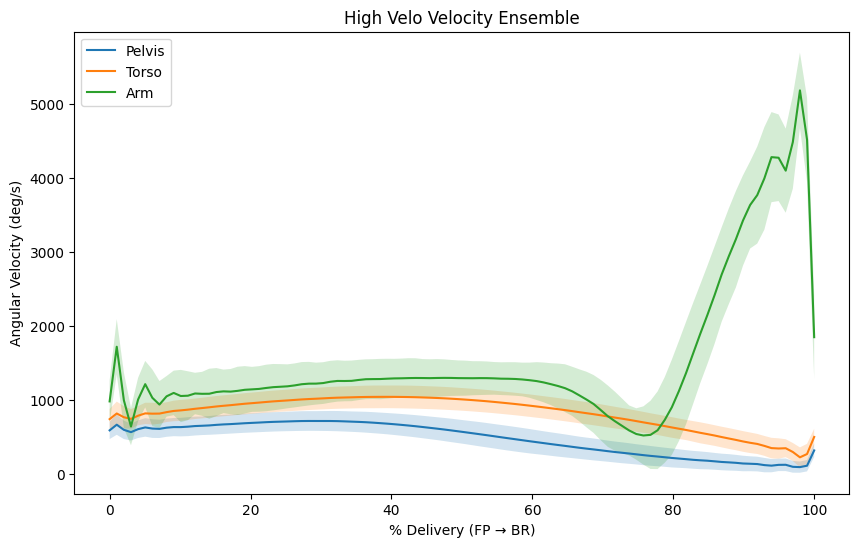

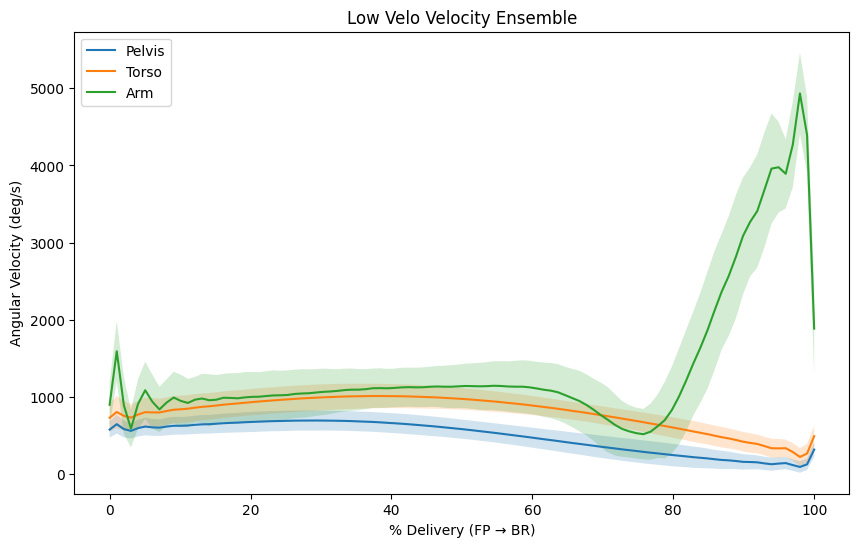

In [ ]:
def plot_ensemble(group_label):

    pitchers = results_df[results_df["velo_group"] == group_label]["session_pitch"]

    pelvis_all, torso_all, shoulder_all = [], [], []

    for sp in pitchers:
        df_pitch = joint_velos[joint_velos["session_pitch"] == sp]
        out = normalize_fp_to_br(df_pitch)
        if out is None:
            continue

        norm, _ = out
        pelvis_all.append(np.abs(norm["pelvis_velo_z"]))
        torso_all.append(np.abs(norm["torso_velo_z"]))
        shoulder_all.append(np.abs(norm["shoulder_velo_z"]))

    pelvis_all = np.array(pelvis_all)
    torso_all = np.array(torso_all)
    shoulder_all = np.array(shoulder_all)

    x = np.linspace(0, 100, pelvis_all.shape[1])

    plt.figure(figsize=(10, 6))
    for data, label in zip(
        [pelvis_all, torso_all, shoulder_all],
        ["Pelvis", "Torso", "Arm"]
    ):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        plt.plot(x, mean, label=label)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(f"{group_label} Velocity Ensemble")
    plt.xlabel("% Delivery (FP → BR)")
    plt.ylabel("Angular Velocity (deg/s)")
    plt.legend()
    plt.show()

plot_ensemble("High Velo")
plot_ensemble("Low Velo")